In [38]:
import pandas as pd
import numpy as np
import re #(data cleaning)
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # Corrected case of WordCloud

#Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [39]:
from nltk.sem.drt import DrtFunctionVariableExpression
data = {
    "reviews":[
    "The product quality is excellent and delivery was very fast.",
    "I am very disappointed with the service. The item arrived damaged.",
    "The product is okay, but the packaging could be improved.",
    "Amazing experience! I will definitely buy again.",
    "The customer support team was unhelpful and rude.",
    "The product works as expected and offers good value for money.",
    "Delivery was delayed, but the product quality is satisfactory.",
    "I love the design and performance of this product.",
    "The item stopped working after a week of use.",
    "It's an average product with both good and bad features.",
    "Great quality and excellent customer service.",
    "The instructions were confusing and difficult to follow.",
    "I received exactly what was described on the website.",
    "The product is neither great nor terrible, just acceptable.",
    "Waste of money. I would not recommend this product to anyone."
]

}
# creat DataFrame
df = pd.DataFrame(data)

In [40]:
df

,reviews
0,The product quality is excellent and delivery ...
1,I am very disappointed with the service. The i...
2,"The product is okay, but the packaging could b..."
3,Amazing experience! I will definitely buy again.
4,The customer support team was unhelpful and rude.
5,The product works as expected and offers good ...
6,"Delivery was delayed, but the product quality ..."
7,I love the design and performance of this prod...
8,The item stopped working after a week of use.
9,It's an average product with both good and bad...


In [41]:
stop_word = set(stopwords.words('english'))

def clean_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Tokenization
    words = word_tokenize(text)

    # 4. Remove stopwords
    words = [word for word in words if word not in stop_word]

    # 5. Join words back into a sentence
    cleaned_text = " ".join(words)

    return cleaned_text

#apply cleaning function
df['Cleaned_Review']=df['reviews'].apply(clean_text)


print(df[['reviews','Cleaned_Review']])

                                              reviews  \
0   The product quality is excellent and delivery ...   
1   I am very disappointed with the service. The i...   
2   The product is okay, but the packaging could b...   
3    Amazing experience! I will definitely buy again.   
4   The customer support team was unhelpful and rude.   
5   The product works as expected and offers good ...   
6   Delivery was delayed, but the product quality ...   
7   I love the design and performance of this prod...   
8       The item stopped working after a week of use.   
9   It's an average product with both good and bad...   
10      Great quality and excellent customer service.   
11  The instructions were confusing and difficult ...   
12  I received exactly what was described on the w...   
13  The product is neither great nor terrible, jus...   
14  Waste of money. I would not recommend this pro...   

                                    Cleaned_Review  
0          product quality excelle

In [42]:
df

,reviews,Cleaned_Review
0,The product quality is excellent and delivery ...,product quality excellent delivery fast
1,I am very disappointed with the service. The i...,disappointed service item arrived damaged
2,"The product is okay, but the packaging could b...",product okay packaging could improved
3,Amazing experience! I will definitely buy again.,amazing experience definitely buy
4,The customer support team was unhelpful and rude.,customer support team unhelpful rude
5,The product works as expected and offers good ...,product works expected offers good value money
6,"Delivery was delayed, but the product quality ...",delivery delayed product quality satisfactory
7,I love the design and performance of this prod...,love design performance product
8,The item stopped working after a week of use.,item stopped working week use
9,It's an average product with both good and bad...,average product good bad features


In [43]:
sai = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
    sentiment_scores = sai.polarity_scores(review)
    compound = sentiment_scores['compound']

    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['reviews','Sentiment']])


Sentiment Analysis Results
                                              reviews Sentiment
0   The product quality is excellent and delivery ...  Positive
1   I am very disappointed with the service. The i...  Negative
2   The product is okay, but the packaging could b...  Positive
3    Amazing experience! I will definitely buy again.  Positive
4   The customer support team was unhelpful and rude.  Negative
5   The product works as expected and offers good ...  Positive
6   Delivery was delayed, but the product quality ...  Positive
7   I love the design and performance of this prod...  Positive
8       The item stopped working after a week of use.  Negative
9   It's an average product with both good and bad...  Negative
10      Great quality and excellent customer service.  Positive
11  The instructions were confusing and difficult ...  Negative
12  I received exactly what was described on the w...   Neutral
13  The product is neither great nor terrible, jus...  Negative
14  Waste of

In [44]:
all_words = " ".join(df['Cleaned_Review'])
word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 common keywords")
print(word_freq.most_common(10))


Top 10 common keywords
[('product', 8), ('quality', 3), ('excellent', 2), ('delivery', 2), ('service', 2), ('item', 2), ('customer', 2), ('good', 2), ('money', 2), ('great', 2)]


In [45]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_words = negative_words.split()

Complaint_freq = Counter(negative_words)

print("\nMost common Complaint keywords")
print(Complaint_freq.most_common(10))


Most common Complaint keywords
[('product', 3), ('item', 2), ('disappointed', 1), ('service', 1), ('arrived', 1), ('damaged', 1), ('customer', 1), ('support', 1), ('team', 1), ('unhelpful', 1)]


In [46]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,7
Negative,7
Neutral,1


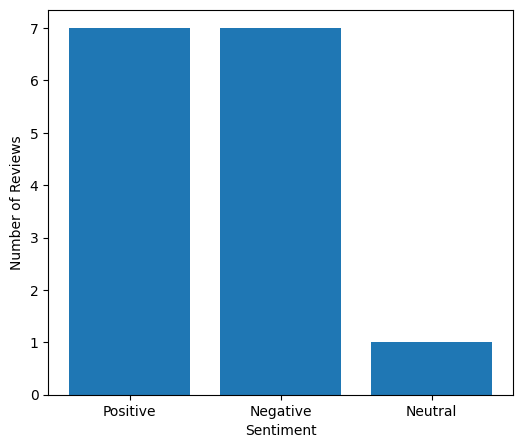

In [47]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

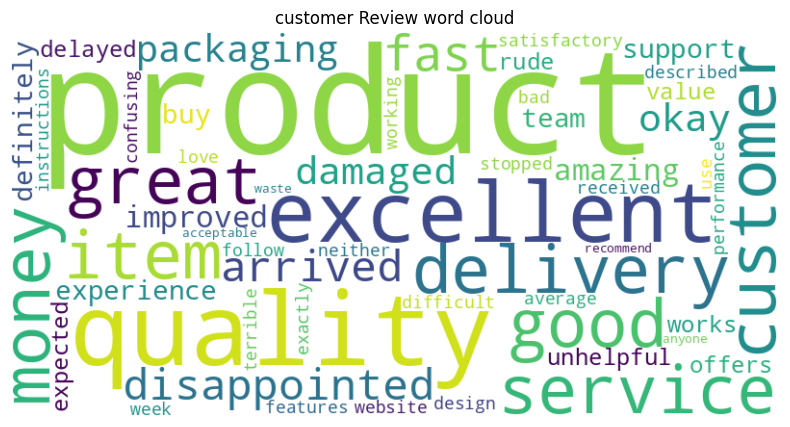

In [49]:
wordcloud = WordCloud(
 width=800,
 height=400,
 background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("customer Review word cloud")
plt.show()

In [50]:
print("*\nBusiness Insights")
print("-------------------------")

positive_count = len(df[df['Sentiment'] == 'positive'])
negative_count = len(df[df['Sentiment'] == 'negative'])
neutral_count = len(df[df['Sentiment'] == 'neutral'])

print("Total Positive Reviews:", positive_count)
print("Total Negative Reviews:", negative_count)
print("Total Neutral Reviews:", neutral_count)

print("\nCommon Positive Areas:")
print(".Product quality")
print(".Fast delivery")
print(".Good Customer Service")

print("\common customer complaints:")
print(".Delayed delivery")
print(".Damaged products")


*
Business Insights
-------------------------
Total Positive Reviews: 0
Total Negative Reviews: 0
Total Neutral Reviews: 0

Common Positive Areas:
.Product quality
.Fast delivery
.Good Customer Service
\common customer complaints:
.Delayed delivery
.Damaged products


<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2152/3860724127.py:17: SyntaxWarning: invalid escape sequence '\c'
  print("\common customer complaints:")
